# Aula 07 Hands-On — Otimização e Regularização em um MLP Fixo

## Contexto
Nesta prática, a arquitetura deixa de ser a variável principal. Mantemos um MLP fixo e observamos como a escolha de otimizador, regularização e taxa de aprendizado altera convergência, estabilidade e generalização. Isso é essencial porque, em projetos reais, muitas melhorias vêm mais do desenho do treinamento do que da troca de modelo.

## Objetivos de aprendizagem
- Comparar SGD puro, SGD com momentum e AdamW sob o mesmo problema.
- Medir o efeito de `weight decay`, dropout e scheduler na lacuna treino-validação.
- Quantificar variância entre sementes em vez de confiar em uma única execução.
- Fazer uma busca pequena e controlada de hiperparâmetros para ilustrar HPO sem depender de bibliotecas externas.

## Pergunta experimental e hipótese
**Pergunta:** se a arquitetura permanece fixa, escolhas de otimização e regularização alteram de forma relevante o desempenho final e a estabilidade do treinamento?

**Hipótese:**
- SGD puro deve convergir, mas com maior sensibilidade a escala de passo.
- Momentum deve melhorar a velocidade e reduzir oscilações.
- AdamW com regularização coerente e scheduler simples deve produzir a melhor combinação entre desempenho e robustez.

## Setup, imports e semente de reprodutibilidade
Usaremos o dataset de dígitos novamente, mas agora com menos dados de treino e um pequeno ruído de rótulo para tornar o problema mais sensível a overfitting. Essa escolha ajuda a expor a utilidade da regularização.

In [1]:
import itertools
import random
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
plt.style.use('seaborn-v0_8-whitegrid')
device

'cuda'

## Carregamento do dataset e desenho experimental
O experimento usa apenas uma fração do conjunto de treino e adiciona ruído controlado a uma pequena parcela dos rótulos. Isso cria uma situação em que a generalização depende claramente do regime de otimização, não apenas da capacidade do MLP.

In [2]:
digits = load_digits()
X = digits.data.astype(np.float32) / 16.0
y = digits.target.astype(np.int64)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.4, stratify=y_train_full, random_state=SEED
)

# reduz o treino para aumentar sensibilidade a regularização
subset_idx = np.random.default_rng(SEED).choice(len(X_train), size=420, replace=False)
X_train = X_train[subset_idx]
y_train = y_train[subset_idx].copy()

# injeta ruído leve de rótulo
noise_idx = np.random.default_rng(SEED + 1).choice(len(y_train), size=int(0.08 * len(y_train)), replace=False)
y_train[noise_idx] = np.random.default_rng(SEED + 2).integers(0, 10, size=len(noise_idx))

def make_loader(X_data, y_data, batch_size=64, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(X_data, dtype=torch.float32),
        torch.tensor(y_data, dtype=torch.long),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader = make_loader(X_val, y_val)
test_loader = make_loader(X_test, y_test)

pd.DataFrame({
    'split': ['treino', 'validação', 'teste'],
    'amostras': [len(X_train), len(X_val), len(X_test)],
})

,split,amostras
0,treino,420
1,validação,575
2,teste,360


## Baseline e por que ele importa
O baseline aqui não é um modelo diferente, e sim o regime mais simples de treinamento: SGD sem momentum, sem scheduler e sem regularização explícita. Essa referência é importante porque ela mostra o que a arquitetura entrega quando o otimizador faz o mínimo possível para estabilizar o processo.

In [3]:
configs = {
    'sgd_base': {'optimizer': 'sgd', 'lr': 0.05, 'weight_decay': 0.0, 'dropout': 0.0, 'momentum': 0.0, 'scheduler': None},
    'sgd_momentum': {'optimizer': 'sgd', 'lr': 0.05, 'weight_decay': 0.0, 'dropout': 0.1, 'momentum': 0.9, 'scheduler': None},
    'adamw_cosine': {'optimizer': 'adamw', 'lr': 0.003, 'weight_decay': 1e-4, 'dropout': 0.2, 'momentum': 0.0, 'scheduler': 'cosine'},
}
list(configs)

['sgd_base', 'sgd_momentum', 'adamw_cosine']

## Método principal
O MLP permanece fixo em todas as comparações. Isso garante que qualquer diferença observada venha do regime de otimização e regularização. A função de treino registra loss de treino, loss de validação, acurácia e o gap entre treino e validação ao longo do processo.

In [4]:
class RegularizedMLP(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.net(x)

def evaluate_model(model, loader, criterion):
    model.eval()
    losses, preds, targets = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            losses.append(criterion(logits, yb).item())
            preds.append(logits.argmax(dim=1).cpu().numpy())
            targets.append(yb.cpu().numpy())

    y_true = np.concatenate(targets)
    y_pred = np.concatenate(preds)
    return {
        'loss': float(np.mean(losses)),
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'y_true': y_true,
        'y_pred': y_pred,
    }

def run_config(config, seed=SEED, epochs=30):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    model = RegularizedMLP(dropout=config['dropout']).to(device)
    criterion = nn.CrossEntropyLoss()

    if config['optimizer'] == 'sgd':
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=config['lr'],
            momentum=config['momentum'],
            weight_decay=config['weight_decay'],
        )
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])

    scheduler = None
    if config['scheduler'] == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_state, best_val_loss = None, float('inf')
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        train_metrics = evaluate_model(model, train_loader, criterion)
        val_metrics = evaluate_model(model, val_loader, criterion)
        history.append({
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'val_loss': val_metrics['loss'],
            'train_accuracy': train_metrics['accuracy'],
            'val_accuracy': val_metrics['accuracy'],
            'generalization_gap': train_metrics['accuracy'] - val_metrics['accuracy'],
            'lr': optimizer.param_groups[0]['lr'],
        })

        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            best_state = deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    test_metrics = evaluate_model(model, test_loader, criterion)
    return pd.DataFrame(history), test_metrics, model

## Métricas e interpretação
Acurácia e macro-F1 capturam qualidade final. A diferença entre acurácia de treino e de validação resume o risco de sobreajuste. A curva de `lr` e a rapidez da queda da loss ajudam a distinguir configurações apenas rápidas de configurações realmente estáveis.

In [5]:
seeds = [13, 42, 91]

def aggregate_runs(config_name, config):
    rows = []
    representative_history = None
    for seed in seeds:
        history_df, test_metrics, _ = run_config(config, seed=seed, epochs=30)
        if representative_history is None:
            representative_history = history_df
        rows.append({
            'config': config_name,
            'seed': seed,
            'accuracy': test_metrics['accuracy'],
            'macro_f1': test_metrics['macro_f1'],
            'final_val_gap': history_df['generalization_gap'].iloc[-1],
        })
    return pd.DataFrame(rows), representative_history

## Execução do treinamento, comparação e mini-busca de hiperparâmetros
Primeiro executamos as três configurações principais em múltiplas sementes. Depois fazemos uma busca pequena em `lr` e `weight decay` apenas para AdamW, mantendo o espaço controlado. A ideia é mostrar HPO como procedimento disciplinado, não como loteria indiscriminada. As tabelas abaixo mostram, nesta ordem, o resumo por configuração (`summary_df`), o log do scheduler cosseno do `adamw_cosine` (`lr` e `val_accuracy` por época) e o grid (`search_df`); o painel de gráficos vem em seguida.


,config,accuracy_mean,accuracy_std,macro_f1_mean,gap_mean
1,sgd_momentum,0.926852,0.008486,0.926002,0.002133
2,adamw_cosine,0.916667,0.002778,0.914575,-0.021739
0,sgd_base,0.632407,0.079414,0.600937,0.022112


,epoch,lr,val_accuracy
0,1,0.002992,0.328696
1,2,0.002967,0.375652
2,3,0.002927,0.631304
3,4,0.002870,0.765217
4,5,0.002799,0.840000
5,6,0.002714,0.852174
6,7,0.002615,0.871304
7,8,0.002504,0.871304
8,9,0.002382,0.885217
9,10,0.002250,0.890435


,lr,weight_decay,val_loss_final,test_accuracy
6,0.010,0.0000,0.253854,0.922222
7,0.010,0.0001,0.254583,0.922222
8,0.010,0.0005,0.256133,0.922222
3,0.003,0.0000,0.464108,0.886111
4,0.003,0.0001,0.464120,0.886111
5,0.003,0.0005,0.464145,0.886111
1,0.001,0.0001,1.056156,0.819444
0,0.001,0.0000,1.056245,0.819444
2,0.001,0.0005,1.056300,0.819444


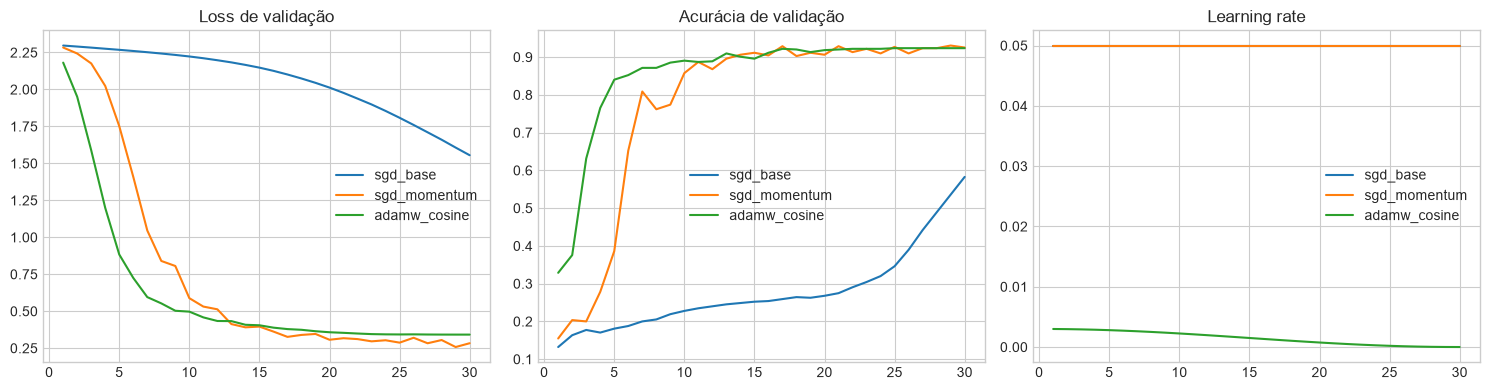

In [6]:
summary_rows = []
representative_histories = {}

for name, config in configs.items():
    run_df, history_df = aggregate_runs(name, config)
    representative_histories[name] = history_df
    summary_rows.append({
        'config': name,
        'accuracy_mean': run_df['accuracy'].mean(),
        'accuracy_std': run_df['accuracy'].std(),
        'macro_f1_mean': run_df['macro_f1'].mean(),
        'gap_mean': run_df['final_val_gap'].mean(),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('accuracy_mean', ascending=False)
display(summary_df)

# log do scheduler cosseno: lr e acurácia de validação por época (semente representativa)
display(representative_histories['adamw_cosine'][['epoch', 'lr', 'val_accuracy']])

search_results = []
for lr, wd in itertools.product([1e-3, 3e-3, 1e-2], [0.0, 1e-4, 5e-4]):
    trial_cfg = {'optimizer': 'adamw', 'lr': lr, 'weight_decay': wd, 'dropout': 0.2, 'momentum': 0.0, 'scheduler': 'cosine'}
    history_df, metrics, _ = run_config(trial_cfg, seed=SEED, epochs=20)
    search_results.append({
        'lr': lr,
        'weight_decay': wd,
        'val_loss_final': history_df['val_loss'].iloc[-1],
        'test_accuracy': metrics['accuracy'],
    })

search_df = pd.DataFrame(search_results).sort_values(['val_loss_final', 'test_accuracy'])
display(search_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for name, history_df in representative_histories.items():
    axes[0].plot(history_df['epoch'], history_df['val_loss'], label=name)
    axes[1].plot(history_df['epoch'], history_df['val_accuracy'], label=name)
    axes[2].plot(history_df['epoch'], history_df['lr'], label=name)
axes[0].set_title('Loss de validação')
axes[1].set_title('Acurácia de validação')
axes[2].set_title('Learning rate')
for ax in axes:
    ax.legend()
plt.tight_layout()

## Análise de erro, limitações e próximo experimento
Aqui queremos separar três efeitos: velocidade de convergência, generalização e sensibilidade à semente. A melhor configuração não é apenas a que maximiza acurácia média, mas a que mantém baixa variância e gap de generalização controlado. O próximo experimento natural é substituir a busca em grade por Optuna ou ASHA e repetir o protocolo com orçamento explícito de trials.

best_cfg: lr=0.01 · weight_decay=0.0 · acurácia de teste (30 épocas) = 0.9389


,config,accuracy_mean,accuracy_std,macro_f1_mean,gap_mean
1,sgd_momentum,0.926852,0.008486,0.926002,0.002133
2,adamw_cosine,0.916667,0.002778,0.914575,-0.021739
0,sgd_base,0.632407,0.079414,0.600937,0.022112


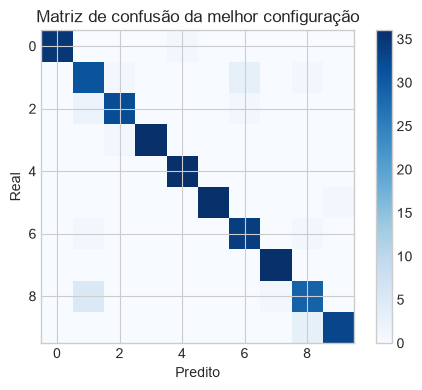

In [7]:
best_cfg = {'optimizer': 'adamw', 'lr': float(search_df.iloc[0]['lr']), 'weight_decay': float(search_df.iloc[0]['weight_decay']), 'dropout': 0.2, 'momentum': 0.0, 'scheduler': 'cosine'}
_, best_metrics, best_model = run_config(best_cfg, seed=SEED, epochs=30)
cm = confusion_matrix(best_metrics['y_true'], best_metrics['y_pred'])
print(f"best_cfg: lr={best_cfg['lr']} · weight_decay={best_cfg['weight_decay']} · "
      f"acurácia de teste (30 épocas) = {best_metrics['accuracy']:.4f}")
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Matriz de confusão da melhor configuração')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.colorbar()
plt.tight_layout()

summary_df

## Fechamento e próximos passos
Se a hipótese estiver correta, o regime AdamW com regularização leve e scheduler deve combinar melhor desempenho e menor variância. Esse resultado prepara a última aula do curso: em vez de perguntar como treinar melhor, vamos perguntar como rastrear, exportar, comprimir e monitorar um modelo depois que ele já foi treinado.